**Шаг 5. Принятие решений по Metrics Driven Development.**  
Вам предоставлены 2 набора данных по времени отклика (latency) и визуализация. Как вы будете в будущем улучшать систему? Продемонстрируйте
навык обоснования архитектурного решения по MDD.

In [41]:
import numpy as np
import scipy.stats as stats
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from math import ceil
import matplotlib.pyplot as plt
import seaborn as sns

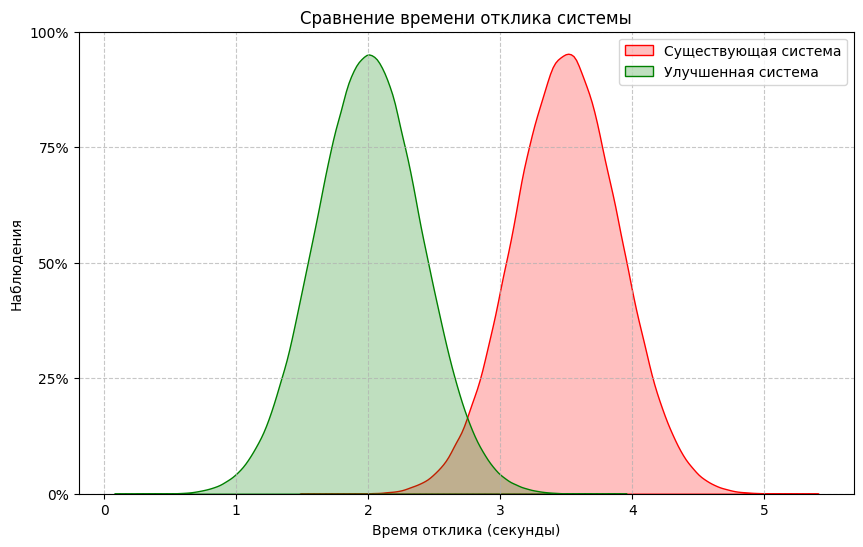

In [2]:
np.random.seed(42); plt.figure(figsize=(10, 6))
existing_system_responses = np.random.normal(loc=3.5, scale=0.4, size=500000)
improved_system_responses = np.random.normal(loc=2.0, scale=0.4, size=500000)
sns.kdeplot(existing_system_responses, label='Существующая система', fill=True, color='red')
sns.kdeplot(improved_system_responses, label='Улучшенная система', fill=True, color='green')
plt.title('Сравнение времени отклика системы'); plt.xlabel('Время отклика (секунды)')
plt.ylabel('Наблюдения'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
ax = plt.gca(); ymin, ymax = ax.get_ylim(); num_ticks = 5; new_yticks = np.linspace(ymin, ymax, num_ticks)
new_yticklabels = [f'{int((tick / ymax) * 100)}%' if ymax != 0 else '0%' for tick in new_yticks]
ax.set_yticks(new_yticks); ax.set_yticklabels(new_yticklabels); plt.show()

In [49]:
mean_existing = np.mean(existing_system_responses)
print(f'Среднее значение existing_system: {mean_existing:.3f}')
mean_improved = np.mean(improved_system_responses)
print(f'Среднее значение improved_system: {mean_improved:.3f}')
rel_delta = (mean_existing - mean_improved) / mean_existing
print(f'Относительное изменение: {rel_delta:.3f}')

Среднее значение existing_system: 3.500
Среднее значение improved_system: 1.999
Относительное изменение: 0.429


In [50]:
# Необходимый размер каждой из групп
# Стандартный уровень статистической значимости
alpha = 0.05

# Надёжность оценки
gamma = 1 - alpha

# Исходя из полученного соотношения mean_existing и mean_improved
# предполагается фиксировать разницу в результатах на 40 % и более,
# чему например в долях может соответстсвовать изменение от 0,55 до 0,95
effect_size = sms.proportion_effectsize(0.55, 0.95)
required_n = ceil(sms.NormalIndPower().solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=alpha,
    ratio=1
))
print(f'Необходимый размер каждой из групп: {required_n}')
print(f'Необходимый суммарный объём выборки: {2*required_n}')

Необходимый размер каждой из групп: 16
Необходимый суммарный объём выборки: 32


In [51]:
# Из-за достаточно большой величины наблюдаемого эффекта
# большие выборки для его подтверждения не требуются
# достаточно взять из каждой совокупности по 1000 записей
# в т.ч. для снижение разницы в дисперсиях выборок

# Выборка из existing_system_responses
existing_sample = np.random.choice(
    existing_system_responses,
    size=1000,
    replace=True
)

# Выборка из improved_system_responses
improved_sample = np.random.choice(
    improved_system_responses,
    size=1000,
    replace=True
)

variance_existing_sample = np.var(existing_sample)
variance_improved_sample = np.var(improved_sample)
print(f'Разница в дисперсии между выборками {
    abs(variance_existing_sample-variance_improved_sample) * 100
/ max([variance_existing_sample, variance_improved_sample]):.2f
} %')

Разница в дисперсии между выборками 0.85 %


In [52]:
# t-тест Стьюдента
z_stat, p_value = stats.ttest_ind(existing_sample, improved_sample)
print(f'Z-статистика: {z_stat:.2f}')
print(f'p-value: {p_value:.4f}')
if p_value < alpha:
    print('H0 отвергается в пользу H1')
else:
    print('Принимается H0')

# Доверительные интервалы сэмплов
std_err = stats.sem(existing_sample)
mean = np.mean(existing_sample)
h = std_err * stats.t.ppf((1 + gamma) / 2, 999)
lower_bound = mean - h
upper_bound = mean + h
print(f"Доверительный интервал existing: ({lower_bound:.4f}, {upper_bound:.4f})")
std_err = stats.sem(improved_sample)
mean = np.mean(improved_sample)
h = std_err * stats.t.ppf((1 + gamma) / 2, 999)
lower_bound = mean - h
upper_bound = mean + h
print(f"Доверительный интервал improved: ({lower_bound:.4f}, {upper_bound:.4f})")

Z-статистика: 84.08
p-value: 0.0000
H0 отвергается в пользу H1
Доверительный интервал existing: (3.4773, 3.5262)
Доверительный интервал improved: (1.9916, 2.0408)


In [53]:
import os
os.environ["PATH"] += ":/content/adr-tools/src"
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/npryce/adr-tools.git >/dev/null
!adr init /content/drive/MyDrive/adr_records
!cd /content/drive/MyDrive/adr_records

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'adr-tools' already exists and is not an empty directory.
/content/drive/MyDrive/adr_records/0007-record-architecture-decisions.md


In [54]:
%%writefile /content/drive/MyDrive/adr_records/0002-decide-on-ml-system-architecture-improvement.md
# decide-on-ml-system-architecture-improvement

Date: 2026-05-31

## Статус

Принято

## Контекст

Была оценена статистическая значимость изменения быстродействия ML-системы (latency).
Статистические данные показали различие между выборками бэйслайновой и улучшенной систем более 40 %: снижение latency с 2 до 3,5 с.
Если полученый результат будет иметь статистическую значимость, то будет подтверждена объективная необходимость совершенствования инфраструктуры системы.
Для статистического теста принимается уровень значимости 0,05 (alpha).
В соответствии с заявленым уровнем улучшения метрики, уровнем статистической значимости, а также мощностью (power=0.8) расчитан требуемый размер выборок для стат.теста - менее 100 в каждой.
Статичтическая значимость проверяется с помощью двустороннего t-теста Стьюдента. Этот тест требует равенство дисперсий выборок, поэтому размеры выборок увеличиваются до 1000 каждая.
Приняты гипотезы: нулевая (H0) - между выборками нет различий и альтернативная гипотеза (H1) - есть статистически значимое различие.
В результате t-теста Стьюдента получено p-value = 0.0000, что говорит о необходимости принятия альтернативной гипотезы.
Также для двух выборок были, при данной alpha, рассчитаны доверительные интервалы и показано, что они даже не пересекаются.

## Решено

Для повышения надёжности ML-системы в краткосрочной перспективе, будет введена асинхронная обработка запросов и очереди задач.
Применение Background Tasks из fastapi позволит разрузить API для приёма новых запросов и их адресации микросервисам.
Для того чтобы контейнеры не конкурировали за ресурсы им должны быть установлены лимиты. Тогда наиболее важные из них, например расчёт по текущему запросу клиента, всегда будут работать стабильно.
Для повышения надёжности ML-системы в долгосрочной перспективе, будет создано несколько реплик API c Nginx-балансировщиком.
Дополнительно, для расчётов модели по запросам из API, предусмотреть GPU на виртуальных машинах, что ускорит работу сложных ML-моделей.

## Последствия

Позитивные:
1. Позитивными последствиями всех принятых решений (краткосрочных и долгосрочных) является повышение быстродействия системы в целом.
2. Применение GPU и установка лимитов ресурсов для контейнеров одновременно сократит время ожидания заказчика.

Негативные:
1. Асинхронная обработка запросов и горизонтальное масштабирование системы не улучшают пользовательский опыт - если у клиента тяжёлый батч, он всё-равно будет ждать долго.
2. Как горизонтальное масштабирование (возможно, с использованием нескольких ВМ), так и переход на GPU связаны с существенными дополнительными затратами. Может потребоваться GPU-совместимость библиотек.

Overwriting /content/drive/MyDrive/adr_records/0002-decide-on-ml-system-architecture-improvement.md
